In [7]:
print("Hotel Bar Inventory Forecasting Project")
print("Starting the project...")


Hotel Bar Inventory Forecasting Project
Starting the project...


## 1. Data Loading and Initial Exploration

The dataset contains transaction-level inventory records for multiple bars and alcohol brands. We first load the data and inspect its structure, columns, missing values, and dimensions.
# New Section

In [8]:
import pandas as pd

df = pd.read_csv("/Consumption Dataset - Dataset.csv")

df.head()


,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml)
0,1/1/2023 19:35,Smith's Bar,Rum,Captain Morgan,2555.04,1824.84,0.0,4379.88
1,1/1/2023 10:07,Smith's Bar,Wine,Yellow Tail,1344.37,0.00,0.0,1344.37
2,1/1/2023 11:26,Johnson's Bar,Vodka,Grey Goose,1034.28,0.00,0.0,1034.28
3,1/1/2023 13:53,Johnson's Bar,Beer,Coors,2194.53,0.00,0.0,2194.53
4,1/1/2023 22:28,Johnson's Bar,Wine,Yellow Tail,1020.90,0.00,0.0,1020.90


In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Hotel Bar Inventory Demand Forecasting

This project analyzes historical hotel bar inventory data to understand consumption patterns, forecast demand, calculate inventory Par Levels, and simulate replenishment decisions.


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [11]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 6575
Number of columns: 8


In [12]:
print(df.columns.tolist())

['Date Time Served', 'Bar Name', 'Alcohol Type', 'Brand Name', 'Opening Balance (ml)', 'Purchase (ml)', 'Consumed (ml)', 'Closing Balance (ml)']


In [13]:
df.isnull().sum()


,0
Date Time Served,0
Bar Name,0
Alcohol Type,0
Brand Name,0
Opening Balance (ml),0
Purchase (ml),0
Consumed (ml),0
Closing Balance (ml),0


## 2. Data Preparation

The transaction timestamp is converted into a datetime format so that we can perform date-based analysis such as daily demand and day-of-week analysis.

In [14]:
df["Date Time Served"] = pd.to_datetime(df["Date Time Served"])

print("Start date:", df["Date Time Served"].min())
print("End date:", df["Date Time Served"].max())

Start date: 2023-01-01 10:07:00
End date: 2024-01-01 22:46:00


In [15]:
print("Number of bars:", df["Bar Name"].nunique())

print("\nBars:")
print(df["Bar Name"].unique())

Number of bars: 6

Bars:
["Smith's Bar" "Johnson's Bar" "Brown's Bar" "Taylor's Bar"
 "Anderson's Bar" "Thomas's Bar"]


In [16]:
print("Number of brands:", df["Brand Name"].nunique())

print("\nBrands:")
print(df["Brand Name"].unique())

Number of brands: 16

Brands:
['Captain Morgan' 'Yellow Tail' 'Grey Goose' 'Coors' 'Jim Beam' 'Absolut'
 'Jack Daniels' 'Sutter Home' 'Miller' 'Bacardi' 'Malibu' 'Jameson'
 'Smirnoff' 'Budweiser' 'Heineken' 'Barefoot']


In [17]:
print("Number of alcohol types:", df["Alcohol Type"].nunique())

print("\nAlcohol types:")
print(df["Alcohol Type"].unique())

Number of alcohol types: 5

Alcohol types:
['Rum' 'Wine' 'Vodka' 'Beer' 'Whiskey']


### Inventory Balance Validation

We validate the inventory records using the relationship:

Closing Balance = Opening Balance + Purchase - Consumed

Small differences caused by floating-point precision are ignored using a tolerance, while meaningful mismatches are identified.

In [18]:
df["Calculated Closing"] = (
    df["Opening Balance (ml)"]
    + df["Purchase (ml)"]
    - df["Consumed (ml)"]
)

df["Difference"] = (
    df["Closing Balance (ml)"]
    - df["Calculated Closing"]
)

print("Number of records:", len(df))
print("Records with mismatch:", (df["Difference"] != 0).sum())

Number of records: 6575
Records with mismatch: 2240


In [19]:
tolerance = 0.01

real_mismatches = df[df["Difference"].abs() > tolerance]

print("Real mismatches:", len(real_mismatches))

Real mismatches: 149


In [20]:
real_mismatches.head(10)

,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),Calculated Closing,Difference
42,2023-01-03 20:00:00,Brown's Bar,Whiskey,Jim Beam,826.20,0.00,227.73,598.0,598.47,-0.47
58,2023-01-04 10:45:00,Smith's Bar,Beer,Miller,2300.00,0.00,349.22,1950.0,1950.78,-0.78
99,2023-01-06 13:10:00,Johnson's Bar,Wine,Barefoot,1427.79,0.00,248.86,1180.0,1178.93,1.07
125,2023-01-07 14:01:00,Taylor's Bar,Whiskey,Jim Beam,2510.00,0.00,494.68,2010.0,2015.32,-5.32
143,2023-01-08 14:46:00,Taylor's Bar,Rum,Captain Morgan,126.78,1736.61,569.99,1290.0,1293.40,-3.40
162,2023-01-09 13:49:00,Brown's Bar,Beer,Coors,1860.00,0.00,444.47,1420.0,1415.53,4.47
174,2023-01-09 10:09:00,Thomas's Bar,Whiskey,Jameson,905.40,0.00,517.22,388.0,388.18,-0.18
179,2023-01-10 20:13:00,Smith's Bar,Beer,Coors,2790.00,1416.82,583.52,3620.0,3623.30,-3.30
245,2023-01-13 22:04:00,Brown's Bar,Beer,Budweiser,4280.00,0.00,451.47,3830.0,3828.53,1.47
251,2023-01-13 17:21:00,Anderson's Bar,Whiskey,Jim Beam,2000.00,722.20,424.82,2300.0,2297.38,2.62


In [21]:
print("Total consumption (ml):", df["Consumed (ml)"].sum())
print("Average consumption per record (ml):", df["Consumed (ml)"].mean())
print("Minimum consumption (ml):", df["Consumed (ml)"].min())
print("Maximum consumption (ml):", df["Consumed (ml)"].max())

Total consumption (ml): 1968681.66
Average consumption per record (ml): 299.419263878327
Minimum consumption (ml): 0.0
Maximum consumption (ml): 1180.58


## 3. Exploratory Data Analysis

We analyze consumption by brand, bar, and day of the week to identify high-velocity products, differences between locations, and demand patterns.

In [22]:
brand_consumption = (
    df.groupby("Brand Name")["Consumed (ml)"]
    .sum()
    .sort_values(ascending=False)
)

brand_consumption

,Consumed (ml)
Brand Name,
Grey Goose,158924.02
Jim Beam,139702.43
Captain Morgan,138035.53
Barefoot,132312.95
Yellow Tail,129843.65
Smirnoff,129176.67
Bacardi,127951.80
Malibu,127279.51
Jack Daniels,125050.89


In [23]:
brand_abc = brand_consumption.to_frame(name="Total Consumption")

brand_abc["Percentage"] = (
    brand_abc["Total Consumption"]
    / brand_abc["Total Consumption"].sum()
    * 100
)

brand_abc["Cumulative Percentage"] = brand_abc["Percentage"].cumsum()

brand_abc

,Total Consumption,Percentage,Cumulative Percentage
Brand Name,,,
Grey Goose,158924.02,8.072611,8.072611
Jim Beam,139702.43,7.096243,15.168854
Captain Morgan,138035.53,7.011572,22.180426
Barefoot,132312.95,6.720891,28.901317
Yellow Tail,129843.65,6.595462,35.496779
Smirnoff,129176.67,6.561582,42.058362
Bacardi,127951.80,6.499365,48.557726
Malibu,127279.51,6.465215,55.022942
Jack Daniels,125050.89,6.352012,61.374953


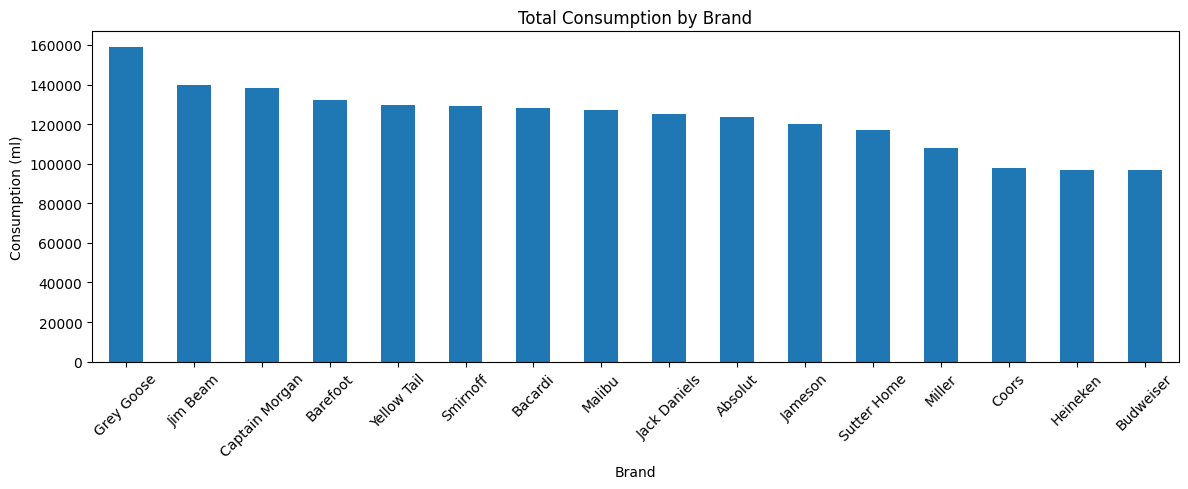

In [24]:
brand_consumption.plot(kind="bar", figsize=(12, 5))

plt.title("Total Consumption by Brand")
plt.xlabel("Brand")
plt.ylabel("Consumption (ml)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [25]:
bar_consumption = (
    df.groupby("Bar Name")["Consumed (ml)"]
    .sum()
    .sort_values(ascending=False)
)

bar_consumption

,Consumed (ml)
Bar Name,
Johnson's Bar,344184.38
Anderson's Bar,335818.95
Smith's Bar,328713.91
Brown's Bar,326371.92
Thomas's Bar,318415.94
Taylor's Bar,315176.56


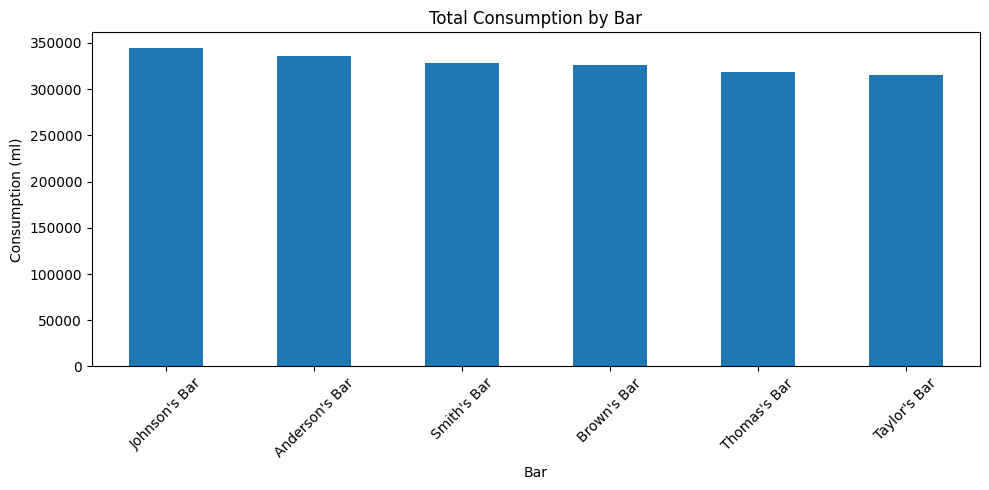

In [26]:
bar_consumption.plot(kind="bar", figsize=(10, 5))

plt.title("Total Consumption by Bar")
plt.xlabel("Bar")
plt.ylabel("Consumption (ml)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
df["Day of Week"] = df["Date Time Served"].dt.day_name()

df[["Date Time Served", "Day of Week"]].head()

,Date Time Served,Day of Week
0,2023-01-01 19:35:00,Sunday
1,2023-01-01 10:07:00,Sunday
2,2023-01-01 11:26:00,Sunday
3,2023-01-01 13:53:00,Sunday
4,2023-01-01 22:28:00,Sunday


In [28]:
day_consumption = (
    df.groupby("Day of Week")["Consumed (ml)"]
    .sum()
)

day_consumption

,Consumed (ml)
Day of Week,
Friday,283676.29
Monday,270807.44
Saturday,281922.49
Sunday,282815.93
Thursday,277772.88
Tuesday,279639.15
Wednesday,292047.48


In [29]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_consumption = day_consumption.reindex(day_order)

day_consumption

,Consumed (ml)
Day of Week,
Monday,270807.44
Tuesday,279639.15
Wednesday,292047.48
Thursday,277772.88
Friday,283676.29
Saturday,281922.49
Sunday,282815.93


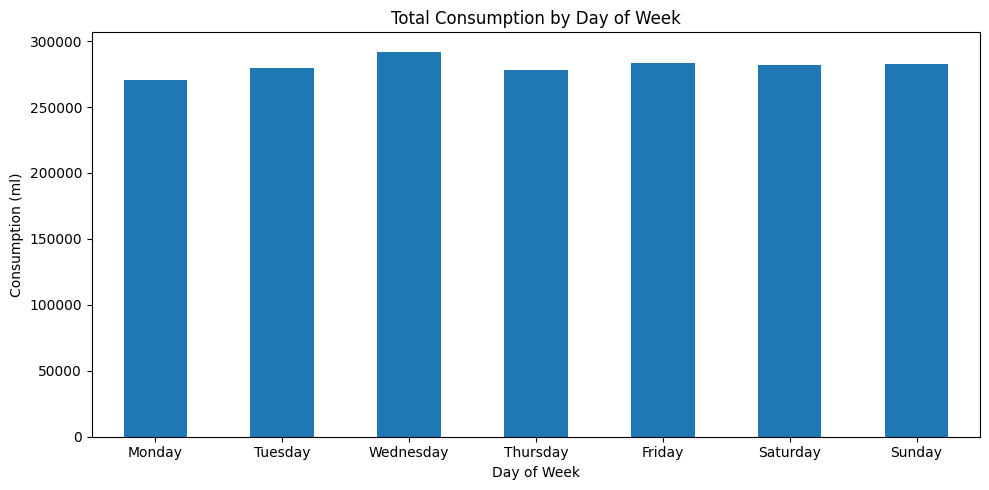

In [30]:
day_consumption.plot(kind="bar", figsize=(10, 5))

plt.title("Total Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Consumption (ml)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Zero Consumption and Historical Stockouts

Zero-consumption records are identified to understand periods with no recorded demand. We also identify records where the closing inventory balance is zero as a historical stockout indicator.

In [31]:
zero_consumption = (df["Consumed (ml)"] == 0).sum()

print("Zero-consumption records:", zero_consumption)
print("Percentage of records:", zero_consumption / len(df) * 100)

Zero-consumption records: 910
Percentage of records: 13.840304182509506


In [32]:
zero_by_brand = (
    df.groupby("Brand Name")["Consumed (ml)"]
    .apply(lambda x: (x == 0).sum())
    .sort_values(ascending=False)
)

zero_by_brand

,Consumed (ml)
Brand Name,
Yellow Tail,102
Sutter Home,73
Smirnoff,70
Jack Daniels,70
Jameson,66
Malibu,64
Absolut,63
Miller,63
Captain Morgan,61


In [33]:
zero_rate_by_brand = (
    df.groupby("Brand Name")["Consumed (ml)"]
    .apply(lambda x: (x == 0).mean() * 100)
    .sort_values(ascending=False)
)

zero_rate_by_brand

,Consumed (ml)
Brand Name,
Yellow Tail,21.294363
Sutter Home,17.675545
Miller,17.355372
Jack Daniels,16.166282
Smirnoff,16.129032
Jameson,15.420561
Malibu,15.058824
Absolut,14.583333
Coors,13.846154


## 4. Daily Demand Aggregation

Transaction-level consumption is aggregated into daily demand for each Bar-Brand combination. A complete date-Bar-Brand grid is created so that days with no recorded consumption are represented as zero demand.


In [34]:
df["Date"] = df["Date Time Served"].dt.date

df[["Date Time Served", "Date"]].head()

,Date Time Served,Date
0,2023-01-01 19:35:00,2023-01-01
1,2023-01-01 10:07:00,2023-01-01
2,2023-01-01 11:26:00,2023-01-01
3,2023-01-01 13:53:00,2023-01-01
4,2023-01-01 22:28:00,2023-01-01


In [35]:
daily_demand = (
    df.groupby(["Date", "Bar Name", "Brand Name"])["Consumed (ml)"]
    .sum()
    .reset_index()
)

daily_demand.head()

,Date,Bar Name,Brand Name,Consumed (ml)
0,2023-01-01,Anderson's Bar,Bacardi,0.0
1,2023-01-01,Anderson's Bar,Jim Beam,0.0
2,2023-01-01,Anderson's Bar,Miller,0.0
3,2023-01-01,Anderson's Bar,Sutter Home,0.0
4,2023-01-01,Brown's Bar,Captain Morgan,0.0


In [36]:
print("Original records:", len(df))
print("Daily demand records:", len(daily_demand))
print("Unique dates:", daily_demand["Date"].nunique())
print("Unique bar-brand combinations:",
      daily_demand[["Bar Name", "Brand Name"]].drop_duplicates().shape[0])

Original records: 6575
Daily demand records: 6575
Unique dates: 366
Unique bar-brand combinations: 96


In [37]:
# Create all possible combinations of Date, Bar, and Brand

all_dates = pd.date_range(
    start=daily_demand["Date"].min(),
    end=daily_demand["Date"].max(),
    freq="D"
)

all_bars = df["Bar Name"].unique()
all_brands = df["Brand Name"].unique()

full_grid = pd.MultiIndex.from_product(
    [all_dates, all_bars, all_brands],
    names=["Date", "Bar Name", "Brand Name"]
).to_frame(index=False)

full_grid.head()

,Date,Bar Name,Brand Name
0,2023-01-01,Smith's Bar,Captain Morgan
1,2023-01-01,Smith's Bar,Yellow Tail
2,2023-01-01,Smith's Bar,Grey Goose
3,2023-01-01,Smith's Bar,Coors
4,2023-01-01,Smith's Bar,Jim Beam


In [39]:
daily_demand["Date"] = pd.to_datetime(daily_demand["Date"])

daily_demand = full_grid.merge(
    daily_demand,
    on=["Date", "Bar Name", "Brand Name"],
    how="left"
)

daily_demand["Consumed (ml)"] = daily_demand["Consumed (ml)"].fillna(0)

print("Daily demand records:", len(daily_demand))

Daily demand records: 35136


In [40]:
stockouts = (df["Closing Balance (ml)"] == 0).sum()

print("Stockout records:", stockouts)
print("Stockout percentage:", round(stockouts / len(df) * 100, 2), "%")

Stockout records: 416
Stockout percentage: 6.33 %


## 5. Demand Forecasting

We aggregate daily demand and use a time-based 80/20 train-test split. A 7-day moving-average baseline is compared with an Exponential Smoothing model using MAE and WAPE.

In [41]:
daily_total = (
    daily_demand.groupby("Date")["Consumed (ml)"]
    .sum()
    .reset_index()
)

daily_total.head()

,Date,Consumed (ml)
0,2023-01-01,0.00
1,2023-01-02,6601.69
2,2023-01-03,7124.15
3,2023-01-04,6065.93
4,2023-01-05,8048.48


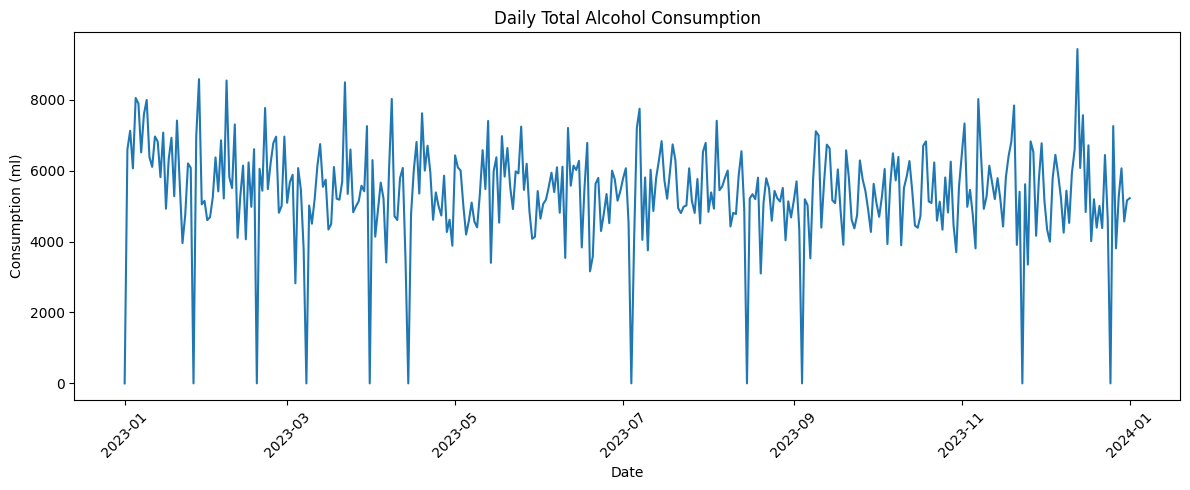

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_total["Date"],
    daily_total["Consumed (ml)"]
)

plt.title("Daily Total Alcohol Consumption")
plt.xlabel("Date")
plt.ylabel("Consumption (ml)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [43]:
split = int(len(daily_total) * 0.8)

train = daily_total.iloc[:split]
test = daily_total.iloc[split:]

print("Training records:", len(train))
print("Testing records:", len(test))

Training records: 292
Testing records: 74


In [44]:
# 7-day moving average baseline
baseline_value = train["Consumed (ml)"].tail(7).mean()

baseline_forecast = np.repeat(
    baseline_value,
    len(test)
)

print("Baseline forecast:", round(baseline_value, 2), "ml/day")

Baseline forecast: 5542.32 ml/day


In [46]:
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(
    test["Consumed (ml)"],
    baseline_forecast
)

baseline_wape = (
    np.sum(np.abs(test["Consumed (ml)"] - baseline_forecast))
    / np.sum(test["Consumed (ml)"])
) * 100

print("Baseline MAE:", round(baseline_mae, 2))
print("Baseline WAPE:", round(baseline_wape, 2), "%")

Baseline MAE: 1028.55
Baseline WAPE: 19.23 %


In [47]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    train["Consumed (ml)"],
    trend="add",
    seasonal=None
)

fit = model.fit()

forecast = fit.forecast(len(test))

print("Forecast records:", len(forecast))

Forecast records: 74


In [48]:
model_mae = mean_absolute_error(
    test["Consumed (ml)"],
    forecast
)

model_wape = (
    np.sum(np.abs(test["Consumed (ml)"] - forecast))
    / np.sum(test["Consumed (ml)"])
) * 100

print("Exponential Smoothing MAE:", round(model_mae, 2))
print("Exponential Smoothing WAPE:", round(model_wape, 2), "%")

Exponential Smoothing MAE: 1028.56
Exponential Smoothing WAPE: 19.23 %


## 6. Inventory Par Level Calculation

Par Levels are calculated for each Bar-Brand combination using lead-time demand and safety stock.

Assumptions:
- Supplier lead time = 2 days
- Service level ≈ 95%
- Z-value = 1.645

Par Level = Lead-Time Demand + Safety Stock

In [49]:
lead_time = 2
z = 1.645

In [51]:
item_stats = (
    daily_demand.groupby(["Bar Name", "Brand Name"])["Consumed (ml)"]
    .agg(["mean", "std"])
    .reset_index()
)

item_stats["Lead Time Demand"] = (
    item_stats["mean"] * lead_time
)

item_stats["Safety Stock"] = (
    z * item_stats["std"] * np.sqrt(lead_time)
)

item_stats["Par Level"] = (
    item_stats["Lead Time Demand"]
    + item_stats["Safety Stock"]
)

item_stats.head()

,Bar Name,Brand Name,mean,std,Lead Time Demand,Safety Stock,Par Level
0,Anderson's Bar,Absolut,35.830355,105.852818,71.660710,246.254018,317.914729
1,Anderson's Bar,Bacardi,70.946639,159.477717,141.893279,371.005981,512.899259
2,Anderson's Bar,Barefoot,73.742158,159.555419,147.484317,371.186744,518.671061
3,Anderson's Bar,Budweiser,27.492596,99.458638,54.985191,231.378716,286.363908
4,Anderson's Bar,Captain Morgan,73.953087,172.006441,147.906175,400.152570,548.058745


## 7. Inventory Simulation

The calculated Bar-Brand Par Levels are used to simulate inventory consumption over the test period. The simulation tracks stockout events and the volume of demand that could not be fulfilled.

In [53]:
# Merge each day's demand with its Bar + Brand Par Level
simulation_data = daily_demand.merge(
    item_stats[["Bar Name", "Brand Name", "Par Level"]],
    on=["Bar Name", "Brand Name"],
    how="left"
)

# Use the last 74 days for simulation
simulation_data["Date"] = pd.to_datetime(simulation_data["Date"])

test_start = simulation_data["Date"].max() - pd.Timedelta(days=73)

simulation_data = simulation_data[
    simulation_data["Date"] >= test_start
].copy()

# Start each Bar + Brand at its own Par Level
inventory = dict(
    zip(
        item_stats["Bar Name"] + "|" + item_stats["Brand Name"],
        item_stats["Par Level"]
    )
)

stockout_days = 0
total_lost = 0

# Simulate day by day
for _, row in simulation_data.iterrows():

    key = row["Bar Name"] + "|" + row["Brand Name"]

    demand = row["Consumed (ml)"]
    par_level = row["Par Level"]

    inventory[key] -= demand

    if inventory[key] < 0:
        total_lost += abs(inventory[key])
        stockout_days += 1
        inventory[key] = 0

    # Replenish when inventory falls below 50% of Par Level
    if inventory[key] <= par_level * 0.5:
        inventory[key] = par_level

print("Simulation records:", len(simulation_data))
print("Stockout events:", stockout_days)
print("Lost Volume:", round(total_lost, 2), "ml")

Simulation records: 7104
Stockout events: 396
Lost Volume: 49404.91 ml


In [54]:
total_par = item_stats["Par Level"].sum()

print("Total Recommended Par Level:", round(total_par, 2), "ml")
print("Stockout Events:", stockout_days)
print("Lost Volume:", round(total_lost, 2), "ml")

Total Recommended Par Level: 42505.65 ml
Stockout Events: 396
Lost Volume: 49404.91 ml


## Simulation Results

The inventory simulation was performed at the Bar-Brand level using the calculated
Par Levels.

- Total recommended Par Level: 42,505.65 ml
- Simulation records: 7,104
- Stockout events: 396
- Lost volume: 49,404.91 ml

The simulation demonstrates how demand variability and dynamically calculated
Par Levels can be used to support inventory replenishment decisions.

## Conclusion

The analysis transformed transaction-level inventory data into daily
Bar-Brand demand and identified consumption patterns, zero-consumption
periods, and historical stockout events.

A 7-day baseline and Exponential Smoothing model were evaluated using MAE
and WAPE. Exponential Smoothing produced results very similar to the
baseline on this dataset.

Bar-Brand Par Levels were calculated using lead-time demand and safety stock
with an assumed 2-day lead time and approximately 95% service level.

The inventory simulation demonstrated the potential impact of using these
Par Levels for replenishment planning.

Future improvements could include real supplier lead-time data, more
advanced item-level forecasting, dynamic reorder points, and a production
inventory monitoring system.